# DATA EXPLORATION & PREPROCESSING

In this notebook, we will explore the data to see what information it provides. We will explore feature engineering and ultimately will construct an anonymized, shuffled data set to prevent data leakage. As we progress through the noteboook, we will extract procedures into functions to go into a `preprocess_data.py` script.

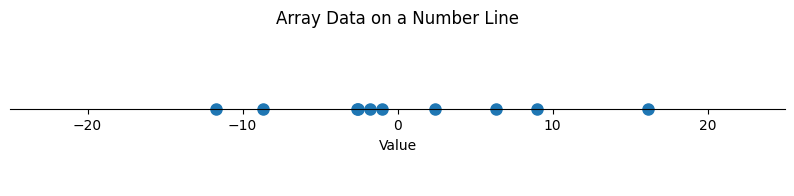

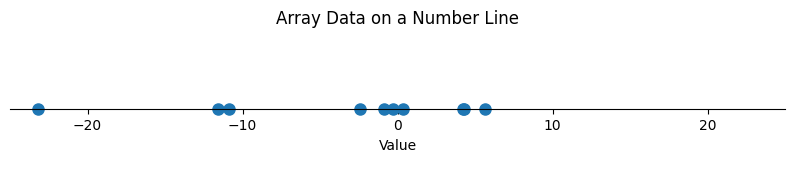

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Define your array of numbers
data = [-8.69, -2.53, -2.62, -1.77, 9.03, 2.39, 16.14, -11.69, -1.03, 6.33]

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 2))

# Plot the points on the number line
# Use a constant y-value (e.g., 0) for all points to keep them on the line
ax.plot(data, np.zeros_like(data), 'o', markersize=8) # 'o' creates circular markers

# Customize the plot
ax.set_yticks([]) # Hide the y-axis ticks as we only need the x-axis
ax.set_xlim(-25, 25) # Set x-axis limits with a small buffer
ax.spines['left'].set_color('none') # Hide the left, top, and right spines
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('center') # Move the x-axis to the center

plt.title("Array Data on a Number Line")
plt.xlabel("Value")
plt.show()

array2 = [-0.31, -23.18, 0.36, -2.4, 4.28, -11.55, 4.22, -10.85, 5.63, -0.89]

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 2))

# Plot the points on the number line
# Use a constant y-value (e.g., 0) for all points to keep them on the line
ax.plot(array2, np.zeros_like(array2), 'o', markersize=8) # 'o' creates circular markers

# Customize the plot
ax.set_yticks([]) # Hide the y-axis ticks as we only need the x-axis
ax.set_xlim(-25, 25) # Set x-axis limits with a small buffer
ax.spines['left'].set_color('none') # Hide the left, top, and right spines
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('center') # Move the x-axis to the center

plt.title("Array Data on a Number Line")
plt.xlabel("Value")
plt.show()

In [192]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
from pathlib import Path
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt 
import seaborn as sns

## STEP 1: LOADING THE DATA
In this section, we load the data by looping over each file, reading it, and concatenating them together into one data set. Then, we'll look at some information regarding the data.

In [193]:
files_to_open = [file for file in sorted(os.listdir("./data/raw/"))]

In [194]:
files_to_open[1], files_to_open[-1], len(files_to_open)

('1968.csv', '2024.csv', 58)

In [195]:
# Load and concat the data
matches_df_list = []
for file in files_to_open[1:]:
    if int(file.split(".")[0]) >= 2000:
        matches_df_list.append(pd.read_csv(Path().cwd()/"data"/"raw"/file))
    else:
        pass

full_matches_df = pd.concat(matches_df_list)

In [196]:
# Check columns
full_matches_df.columns

Index(['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level',
       'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry',
       'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age',
       'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand',
       'loser_ht', 'loser_ioc', 'loser_age', 'score', 'best_of', 'round',
       'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon',
       'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt',
       'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced',
       'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points'],
      dtype='object')

In [197]:
# NAs and dtypes
full_matches_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74906 entries, 0 to 3075
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tourney_id          74906 non-null  object 
 1   tourney_name        74906 non-null  object 
 2   surface             74853 non-null  object 
 3   draw_size           74906 non-null  int64  
 4   tourney_level       74906 non-null  object 
 5   tourney_date        74906 non-null  int64  
 6   match_num           74906 non-null  int64  
 7   winner_id           74906 non-null  int64  
 8   winner_seed         31120 non-null  float64
 9   winner_entry        9506 non-null   object 
 10  winner_name         74906 non-null  object 
 11  winner_hand         74906 non-null  object 
 12  winner_ht           73481 non-null  float64
 13  winner_ioc          74906 non-null  object 
 14  winner_age          74901 non-null  float64
 15  loser_id            74906 non-null  int64  
 16  loser_seed

In [202]:
# Create NA df for easier display
columns = full_matches_df.columns.to_list()
na_counts = [full_matches_df[col].isna().sum() for col in columns]
na_pcts = [round(na_count / full_matches_df.shape[0], 4) for na_count in na_counts]
dtypes = [full_matches_df[col].dtype for col in columns]

na_summary_dict = {
    "Column":columns,
    "DTypes": dtypes,
    "Count of NA Values": na_counts,
    "Percentage NA": na_pcts
}

nas_df = pd.DataFrame(na_summary_dict)
# nas_df.sort_values(by = "Percentage NA", ascending = False)
nas_df

,Column,DTypes,Count of NA Values,Percentage NA
0,tourney_id,object,0,0.0000
1,tourney_name,object,0,0.0000
2,surface,object,53,0.0007
3,draw_size,int64,0,0.0000
4,tourney_level,object,0,0.0000
5,tourney_date,int64,0,0.0000
6,match_num,int64,0,0.0000
7,winner_id,int64,0,0.0000
8,winner_seed,float64,43786,0.5845
9,winner_entry,object,65400,0.8731


In [114]:
df = full_matches_df.copy()

### Deal with NA values

In [115]:
df1 = df.copy()

In [2]:
arr = [1,2,3,4,5]
print(arr)
arr[1] = 5
print(arr)

[1, 2, 3, 4, 5]
[1, 5, 3, 4, 5]


In [116]:
# Columns that we don't need in a match
col_to_drop = [
    "minutes", # Won't know how long a match goes BEFORE played
    "winner_ioc", # Player country doesn't seem like a very useful feature
    "loser_ioc", # Player country doesn't seem like a very useful feature
]

In [117]:
df1["winner_unseeded"] = df1["winner_seed"].isna().astype(int)
df1["loser_unseeded"] = df1["loser_seed"].isna().astype(int)
df1["winner_seed"] = df1["winner_seed"].fillna(0)
df1["loser_seed"] = df1["loser_seed"].fillna(0)

In [118]:
df1[["winner_seed", "winner_unseeded", "loser_unseeded", "loser_seed"]]

,winner_seed,winner_unseeded,loser_unseeded,loser_seed
0,1.0,0,1,0.0
1,0.0,1,1,0.0
2,0.0,1,1,0.0
3,7.0,0,1,0.0
4,0.0,1,0,4.0
...,...,...,...,...
3071,0.0,1,1,0.0
3072,0.0,1,1,0.0
3073,0.0,1,1,0.0
3074,0.0,1,1,0.0


### Standardize `entry` columns

| Abbr. | Meaning |
| ----- | ------- |
| WC | Wild Card | 
| Q | Qualifier | 
| LL | Lucky Loser | 
| PR | Protected Ranking | 
| S | Special Exempt | 
| SE | Special Exempt | 
| ALT | Alternate | 
| W | Wild Card | 
| WC | Wild Card | 
| ITF | ITF wild card -> can probably be reclassified as a WC -> seems only for Olympics (way to represent countries) | 
| UP | University Place -> essentially a WC -> only one row |
| nan | Direct Entry |

In [119]:
df1["winner_entry"].unique()

array([nan, 'Q', 'WC', 'LL', 'PR', 'SE', 'ALT', 'Alt', 'UP', 'ITF', 'W'],
      dtype=object)

In [135]:
df1["winner_entry"] = (
    df["winner_entry"]
    .fillna("DE")
    .str.strip()
    .str.lower()
    .replace({
        " ":"",
        "up":"wc",
        "itf":"wc",
        "w":"wc"

    }))
df1["winner_entry"].unique()

array(['de', 'q', 'wc', 'll', 'pr', 'se', 'alt'], dtype=object)

In [136]:
df1["loser_entry"].unique()

array([nan, 'WC', 'Q', 'LL', 'PR', 'S', 'SE', 'ALT', 'Alt', 'ITF', 'UP',
       'W'], dtype=object)

In [137]:
df1["loser_entry"] = (
    df["loser_entry"]
    .fillna("DE")
    .str.strip()
    .str.lower()
    .replace({
        " ":"",
        "s":"se",
        "up":"wc",
        "itf":"wc",
        "w":"wc"
        
    })
)

df1["loser_entry"].unique()

array(['de', 'wc', 'q', 'll', 'pr', 'se', 'alt'], dtype=object)

### Fix `tourney_date` column

Need to reformat into a string and then convert to date time.

In [140]:
df1[["tourney_date"]].sample(5) # Counted as int in format at YYYYMMDD

,tourney_date
1097,20040419
2028,20150727
416,20070723
1899,20130708
1551,20090105


In [142]:
# Use regex to turn YYYYMMDD into YYYY-MM-DD and convert to datetime dtype
df1["tourney_date"] = df1["tourney_date"].apply(lambda x: f"{str(x)[0:4]}-{str(x)[4:6]}-{str(x)[6:8]}")
df1["tourney_date"] = pd.to_datetime(df1["tourney_date"])

In [143]:
df1["tourney_date"].sample(5)

1900   2013-07-08
1806   2013-06-24
651    2023-03-06
2485   2023-10-16
2271   2024-08-26
Name: tourney_date, dtype: datetime64[ns]

### Explore Surface Column

In [144]:
df2 = df1.copy()

In [145]:
df2["surface"].unique()

array(['Hard', 'Clay', 'Grass', 'Carpet', nan], dtype=object)

In [146]:
df2["surface"].isna().sum()

np.int64(53)

In [147]:
df2[df2["surface"].isna()] # NA values are for Davis Cup matches

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points,winner_unseeded,loser_unseeded
2897,2023-M-DC-2023-WG1-PO-BRA-CHN-01,Davis Cup WG1 PO: BRA vs CHN,NaN,4,D,2023-02-03,1,207799,0.0,de,...,NaN,NaN,NaN,NaN,212.0,263.0,568.0,56.0,1,1
2898,2023-M-DC-2023-WG1-PO-BRA-CHN-01,Davis Cup WG1 PO: BRA vs CHN,NaN,4,D,2023-02-03,2,106329,0.0,de,...,NaN,NaN,NaN,NaN,78.0,690.0,913.0,14.0,1,1
2899,2023-M-DC-2023-WG1-PO-BRA-CHN-01,Davis Cup WG1 PO: BRA vs CHN,NaN,4,D,2023-02-03,4,208361,0.0,de,...,NaN,NaN,NaN,NaN,414.0,107.0,568.0,56.0,1,1
2904,2023-M-DC-2023-WG1-PO-ISR-LAT-01,Davis Cup WG1 PO: ISR vs LAT,NaN,4,D,2023-02-04,1,209866,0.0,de,...,NaN,NaN,NaN,NaN,1215.0,5.0,359.0,134.0,1,1
2905,2023-M-DC-2023-WG1-PO-ISR-LAT-01,Davis Cup WG1 PO: ISR vs LAT,NaN,4,D,2023-02-04,2,105208,0.0,de,...,NaN,NaN,NaN,NaN,289.0,181.0,367.0,130.0,1,1
2906,2023-M-DC-2023-WG1-PO-ISR-LAT-01,Davis Cup WG1 PO: ISR vs LAT,NaN,4,D,2023-02-04,4,200075,0.0,de,...,NaN,NaN,NaN,NaN,476.0,83.0,486.0,78.0,1,1
2907,2023-M-DC-2023-WG1-PO-ISR-LAT-01,Davis Cup WG1 PO: ISR vs LAT,NaN,4,D,2023-02-04,5,131951,0.0,de,...,NaN,NaN,NaN,NaN,367.0,130.0,1215.0,5.0,1,1
2908,2023-M-DC-2023-WG1-PO-PAK-LTU-01,Davis Cup WG1 PO: PAK vs LTU,NaN,4,D,2023-02-03,1,105575,0.0,de,...,NaN,NaN,NaN,NaN,193.0,307.0,NaN,NaN,1,1
2909,2023-M-DC-2023-WG1-PO-PAK-LTU-01,Davis Cup WG1 PO: PAK vs LTU,NaN,4,D,2023-02-03,2,210220,0.0,de,...,NaN,NaN,NaN,NaN,784.0,24.0,NaN,NaN,1,1
2910,2023-M-DC-2023-WG1-PO-PAK-LTU-01,Davis Cup WG1 PO: PAK vs LTU,NaN,4,D,2023-02-03,4,209147,0.0,de,...,NaN,NaN,NaN,NaN,760.0,27.0,NaN,NaN,1,1


In [151]:
# Only concerned with predicting regular ATP tour level matches -> remove all Davis Cup matches
df3 = df2[~df2["tourney_name"].str.contains("Davis Cup")].copy()

In [ ]:
df3["surface"].unique() # No more nan values

array(['Hard', 'Clay', 'Grass', 'Carpet'], dtype=object)

In [ ]:
# Let's also look at carpet matches, these might just be adding noise since carpet has been discontinued on tour since 2008
df3[df3["surface"] == "Carpet"]["tourney_name"].unique() # These are all tournaments that still exist, so we should keep them


array(['Basel', 'Paris Masters', 'Lyon', 'Moscow', 'Milan',
       'St. Petersburg', 'Masters Cup', 'Ho Chi Minh City', 'Zagreb'],
      dtype=object)

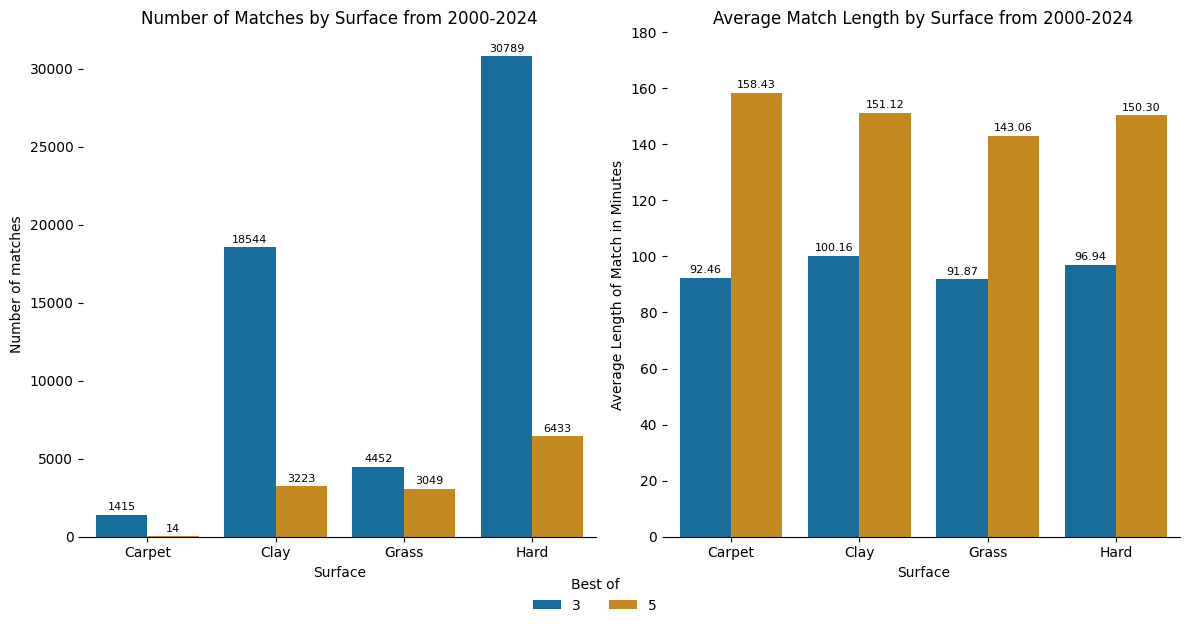

In [155]:
# Group by surfaces and best_of to get general match statistics
surface_matches = df3.groupby(["surface", "best_of"]).agg(
    num_matches = ("surface", "size"),
    surface_avg_match_length = ("minutes", "mean"),
    surface_med_match_length = ("minutes", "median"),
    surface_avg_w_1stWon = ("w_1stWon", "mean"),
    surface_avg_l_1stWon = ("l_1stWon", "mean") 
).reset_index()

# Create side by side plot showing number of matches and avg match duration across different surfaces
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

palette = "colorblind"
sns.barplot(data = surface_matches, x = "surface", y = "num_matches", 
            palette = palette, hue = "best_of", ax = axes[0],)
sns.barplot(data = surface_matches, x = "surface", y = "surface_avg_match_length",
            palette = palette, hue = "best_of", ax = axes[1],legend = False)

# Create legend at bottom of figure
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Best of",
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.05)
)

# Remove upper left legend
if axes[0].legend_:
    axes[0].legend_.remove()

axes[0].set_title("Number of Matches by Surface from 2000-2024")
axes[0].set_ylabel("Number of matches")
axes[0].set_xlabel("Surface")

axes[1].set_title("Average Match Length by Surface from 2000-2024")
axes[1].set_ylabel("Average Length of Match in Minutes")
axes[1].set_xlabel("Surface")
axes[1].set_ylim(0, 180)

# Add bar labels
for cont in axes[0].containers:
    axes[0].bar_label(cont, fontsize = 8, padding = 2)

for cont in axes[1].containers:
    axes[1].bar_label(cont, fmt = "%.2f", fontsize = 8, padding = 2)

# Remove borders
axes[0].spines[["right", "left", "top"]].set_visible(False)
axes[1].spines[["right", "left", "top"]].set_visible(False)

plt.tight_layout()
plt.show()

In [156]:
# Create NA df for easier display
columns = df2.columns.to_list()
na_counts = [df2[col].isna().sum() for col in columns]
na_pcts = [round(na_count / df2.shape[0], 4) for na_count in na_counts]

na_summary_dict = {
    "Column":columns,
    "Count of NA Values": na_counts,
    "Percentage NA": na_pcts
}

nas_df = pd.DataFrame(na_summary_dict)
nas_df.sort_values(by = "Percentage NA", ascending = False)

,Column,Count of NA Values,Percentage NA
26,minutes,8174,0.1091
39,l_1stIn,6520,0.0870
30,w_1stIn,6520,0.0870
28,w_df,6520,0.0870
27,w_ace,6520,0.0870
31,w_1stWon,6520,0.0870
32,w_2ndWon,6520,0.0870
33,w_SvGms,6520,0.0870
34,w_bpSaved,6520,0.0870
35,w_bpFaced,6520,0.0870


Before creating the prediction df, you need to properly select applicable matches. You need to get rid of:
- Defaulted matches, cancelled matches, etc.
- Potentially get rid of world tour finals since those incorporate round robins?
- Potentially get rid of olympics because those have different match structure (?)

In [ ]:
df3[df3["tourney_name"].str.contains("Olympics")]["round"].unique() # BR stands for Broze Medal match -> should go between SF and F

array(['R64', 'R32', 'R16', 'QF', 'SF', 'F', 'BR'], dtype=object)

In [ ]:
df3[(df3["tourney_name"].str.contains("Masters Cup"))]["round"].unique() # RR stands for Round Robin -> should go just before SF

array(['RR', 'SF', 'F'], dtype=object)

In [ ]:
df3[df3["tourney_name"].str.contains("Tour Finals")]["round"].unique() # RR stands for Round Robin -> should go just before SF

array(['RR', 'SF', 'F'], dtype=object)

In [176]:
df3.columns

Index(['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level',
       'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry',
       'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age',
       'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand',
       'loser_ht', 'loser_ioc', 'loser_age', 'score', 'best_of', 'round',
       'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon',
       'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt',
       'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced',
       'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points',
       'winner_unseeded', 'loser_unseeded'],
      dtype='object')

In [178]:
df3["draw_size"].unique()

array([ 32,  56,  48,  96,  64, 128,   8,  28,  16,  24,  12,  18])

In [190]:
df3["tourney_level"].unique()

array(['A', 'M', 'G', 'F', 'O'], dtype=object)

In [191]:
df3[df3["tourney_level"] == "O"]

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points,winner_unseeded,loser_unseeded
1966,2024-0096,Paris Olympics,Clay,64,O,2024-07-29,101,104925,1.0,de,...,2.0,7.0,4.0,10.0,2.0,8460.0,NaN,NaN,0,1
1967,2024-0096,Paris Olympics,Clay,64,O,2024-07-29,102,104745,0.0,pr,...,14.0,13.0,4.0,8.0,161.0,380.0,86.0,685.0,1,1
1968,2024-0096,Paris Olympics,Clay,64,O,2024-07-29,103,136440,0.0,de,...,19.0,18.0,3.0,3.0,70.0,776.0,177.0,340.0,1,1
1969,2024-0096,Paris Olympics,Clay,64,O,2024-07-29,104,208286,0.0,de,...,10.0,11.0,5.0,6.0,45.0,1155.0,23.0,1770.0,1,0
1970,2024-0096,Paris Olympics,Clay,64,O,2024-07-29,105,202104,12.0,de,...,9.0,9.0,2.0,4.0,18.0,2250.0,77.0,745.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025,2024-0096,Paris Olympics,Clay,64,O,2024-07-29,164,207989,2.0,de,...,12.0,10.0,3.0,5.0,3.0,8130.0,13.0,3410.0,0,0
2026,2024-0096,Paris Olympics,Clay,64,O,2024-07-29,165,104925,1.0,de,...,10.0,9.0,8.0,13.0,2.0,8460.0,16.0,2340.0,0,0
2027,2024-0096,Paris Olympics,Clay,64,O,2024-07-29,166,207989,2.0,de,...,4.0,7.0,4.0,9.0,3.0,8130.0,19.0,2115.0,0,0
2028,2024-0096,Paris Olympics,Clay,64,O,2024-07-29,167,104925,1.0,de,...,16.0,12.0,6.0,6.0,2.0,8460.0,3.0,8130.0,0,0


In [189]:
df3[df3["draw_size"] == 128]

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points,winner_unseeded,loser_unseeded
2130,2000-520,Roland Garros,Clay,128,G,2000-05-29,1,101736,1.0,de,...,22.0,16.0,9.0,13.0,1.0,5085.0,116.0,355.0,0,1
2131,2000-520,Roland Garros,Clay,128,G,2000-05-29,2,102344,0.0,de,...,9.0,11.0,14.0,23.0,40.0,845.0,219.0,158.0,1,1
2132,2000-520,Roland Garros,Clay,128,G,2000-05-29,3,103181,0.0,de,...,15.0,23.0,12.0,25.0,88.0,463.0,83.0,494.0,1,1
2133,2000-520,Roland Garros,Clay,128,G,2000-05-29,4,102644,0.0,de,...,17.0,16.0,9.0,17.0,45.0,802.0,110.0,376.0,1,1
2134,2000-520,Roland Garros,Clay,128,G,2000-05-29,5,103454,0.0,de,...,10.0,14.0,5.0,12.0,75.0,579.0,130.0,310.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2309,2024-560,Us Open,Hard,128,G,2024-08-26,222,126203,12.0,de,...,20.0,22.0,11.0,13.0,12.0,3120.0,4.0,7035.0,0,0
2310,2024-560,Us Open,Hard,128,G,2024-08-26,223,126207,20.0,de,...,22.0,18.0,8.0,14.0,20.0,2120.0,9.0,3655.0,0,0
2311,2024-560,Us Open,Hard,128,G,2024-08-26,224,206173,1.0,de,...,32.0,16.0,7.0,11.0,1.0,9360.0,25.0,1695.0,0,0
2312,2024-560,Us Open,Hard,128,G,2024-08-26,225,126203,12.0,de,...,27.0,24.0,5.0,11.0,12.0,3120.0,20.0,2120.0,0,0


# Create match df for prediction

In [52]:
df3.head()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points,winner_unseeded,loser_unseeded
0,2000-301,Auckland,Hard,32,A,2000-01-10,1,103163,1.0,de,...,29.0,17.0,4.0,7.0,11.0,1612.0,63.0,595.0,0,1
1,2000-301,Auckland,Hard,32,A,2000-01-10,2,102607,0.0,q,...,18.0,12.0,3.0,6.0,211.0,157.0,49.0,723.0,1,1
2,2000-301,Auckland,Hard,32,A,2000-01-10,3,103252,0.0,de,...,7.0,8.0,7.0,11.0,48.0,726.0,59.0,649.0,1,1
3,2000-301,Auckland,Hard,32,A,2000-01-10,4,103507,7.0,de,...,14.0,10.0,6.0,8.0,45.0,768.0,61.0,616.0,0,1
4,2000-301,Auckland,Hard,32,A,2000-01-10,5,102103,0.0,q,...,18.0,12.0,5.0,9.0,167.0,219.0,34.0,873.0,1,0


In [50]:
df3.columns

Index(['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level',
       'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry',
       'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age',
       'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand',
       'loser_ht', 'loser_ioc', 'loser_age', 'score', 'best_of', 'round',
       'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon',
       'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt',
       'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced',
       'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points',
       'winner_unseeded', 'loser_unseeded'],
      dtype='object')

In [69]:
new_cols = ["tourney_date", "player_A", "player_B", "player_A_seed", "player_A_unseeded", "player_B_seed", "player_B_unseeded",
            "player_A_entry", "player_B_entry", "player_A_hand", "player_B_hand", "player_A_ht", "player_B_ht", 
            "player_A_age", "player_B_age", "player_A_rank", "player_B_rank", "best_of", "round", "tourney_name",
            "surface", "draw_size", "tourney_level", "player_A_winner"
            ]

rng = np.random.default_rng(100)
def map_to_A_B(row):
    # if random > 0.50 -> set winner to player A
    if rng.random() > 0.50:
        return pd.Series([
            row["tourney_date"],
            row["winner_name"], row["loser_name"], row["winner_seed"], row["winner_unseeded"], 
            row["loser_seed"], row["loser_unseeded"], row["winner_entry"], row["loser_entry"], row["winner_hand"],
            row["loser_hand"], row["winner_ht"], row["loser_ht"], row["winner_age"], row["loser_age"], row["winner_rank"],
            row["loser_rank"], row["best_of"], row["round"], row["tourney_name"], row["surface"], row["draw_size"], 
            row["tourney_level"], 1
        ])
    
    else:
        return pd.Series([
            row["tourney_date"],
            row["loser_name"], row["winner_name"], row["loser_seed"], row["loser_unseeded"], 
            row["winner_seed"], row["winner_unseeded"], row["loser_entry"], row["winner_entry"], 
            row["loser_hand"], row["winner_hand"], row["loser_ht"], row["winner_ht"],
            row["loser_age"], row["winner_age"], row["loser_rank"], row["winner_rank"],
            row["best_of"], row["round"], row["tourney_name"], row["surface"], row["draw_size"], 
            row["tourney_level"], 0
        ])

new_df = df3.apply(map_to_A_B, axis = 1)
new_df.columns = new_cols

In [80]:
new_df
new_df["player_A_ELO"] = 1500
new_df["player_B_ELO"] = 1500

### ELO

In [79]:
new_df.iloc[1]["player_A"]

'Juan Balcells'

In [99]:
new_df["round"].unique()

array(['SF', 'R16', 'R32', 'QF', 'F', 'R128', 'R64', 'RR', 'BR', 'ER'],
      dtype=object)

In [100]:
new_df[new_df["round"] == "ER"]

,tourney_date,player_A,player_B,player_A_seed,player_A_unseeded,player_B_seed,player_B_unseeded,player_A_entry,player_B_entry,player_A_hand,...,player_B_rank,best_of,round,tourney_name,surface,draw_size,tourney_level,player_A_winner,player_A_ELO,player_B_ELO
20706,2007-01-01,Gilles Muller,Alun Jones,0.0,1,0.0,1,de,wc,L,...,200.0,3,ER,Adelaide,Hard,32,A,0,1466.282050,1457.319602
20721,2007-01-01,Paul Baccanello,Frank Dancevic,0.0,1,0.0,1,q,de,R,...,88.0,3,ER,Adelaide,Hard,32,A,0,1460.362360,1463.726811
20725,2007-01-01,Go Soeda,Juan Martin del Potro,0.0,1,0.0,1,q,de,R,...,92.0,3,ER,Adelaide,Hard,32,A,0,1459.630738,1549.210363
20726,2007-01-01,Wesley Moodie,Igor Kunitsyn,0.0,1,0.0,1,q,de,R,...,94.0,3,ER,Adelaide,Hard,32,A,0,1576.922310,1564.043874
20729,2007-01-01,Peter Luczak,Martin Vassallo Arguello,0.0,1,0.0,1,wc,de,R,...,81.0,3,ER,Adelaide,Hard,32,A,1,1477.977098,1508.316633
20740,2007-01-01,Chris Guccione,Amer Delic,0.0,1,0.0,1,wc,de,L,...,93.0,3,ER,Adelaide,Hard,32,A,1,1611.663912,1433.058994
20741,2007-01-01,Lukas Dlouhy,Joachim Johansson,0.0,1,0.0,1,de,de,R,...,193.0,3,ER,Adelaide,Hard,32,A,0,1426.321668,1650.272892
20742,2007-01-01,Nathan Healey,Evgeny Korolev,0.0,1,0.0,1,q,de,R,...,102.0,3,ER,Adelaide,Hard,32,A,0,1464.626306,1520.640441
20939,2007-01-28,Sergiy Stakhovsky,Alejandro Falla,0.0,1,0.0,1,q,de,R,...,103.0,3,ER,Delray Beach,Hard,32,A,0,1512.478647,1457.965457
20945,2007-01-28,Dusan Vemic,Davide Sanguinetti,0.0,1,0.0,1,q,de,R,...,112.0,3,ER,Delray Beach,Hard,32,A,0,1533.793313,1499.478950


In [ ]:
new_df["round_order"] = new_df.map({})

np.int64(0)

In [92]:
player_ELO_dict = {}

new_df = new_df.sort_values(by = "tourney_date").reset_index(drop = True)

# Loops over each row in new_df
for idx, row in new_df.iterrows():
    # Gets player A and B names
    pA, pB = row["player_A"], row["player_B"]

    # Check if we have prematch ELOs for players in dict
    # If not, intialize to 1500
    pA_prematch_ELO = player_ELO_dict.get(pA, 1500)
    pB_prematch_ELO = player_ELO_dict.get(pB, 1500)

    # print(pA_prematch_ELO)
    # print(pB_prematch_ELO)

    # Assign, at the current row's idx, the ELO pulled from above
    new_df.at[idx, "player_A_ELO"] = pA_prematch_ELO
    new_df.at[idx, "player_B_ELO"] = pB_prematch_ELO

    # Calculate expected probabilites of winning for each player
    Ea = 1 / (1 + 10 ** ((pB_prematch_ELO - pA_prematch_ELO) / 400))
    Eb = 1 - Ea

    # Conditionally set K values
    if row["player_A_unseeded"]:
        Ka = 32
    else:
        Ka = 16
    
    if row["player_B_unseeded"]:
        Kb = 32
    else:
        Kb = 16

    # Update ELO scores
    pA_postmatch_ELO = pA_prematch_ELO + (Ka * (row["player_A_winner"] - Ea))
    pB_postmatch_ELO = pB_prematch_ELO + (Kb * ((1 - row["player_A_winner"]) - Eb))

    # Update player ELO dictionary with most recent ELO rating
    player_ELO_dict[pA] = pA_postmatch_ELO
    player_ELO_dict[pB] = pB_postmatch_ELO

    

In [96]:
new_df[(new_df["player_A"] == "Martin Damm Sr") | (new_df["player_B"] == "Martin Damm Sr")]

,tourney_date,player_A,player_B,player_A_seed,player_A_unseeded,player_B_seed,player_B_unseeded,player_A_entry,player_B_entry,player_A_hand,...,player_B_rank,best_of,round,tourney_name,surface,draw_size,tourney_level,player_A_winner,player_A_ELO,player_B_ELO
0,2000-01-03,Martin Damm Sr,Jerome Golmard,0.0,1,4.0,0,de,de,R,...,35.0,3,SF,Chennai,Hard,32,A,0,1500.000000,1500.000000
1,2000-01-03,Martin Damm Sr,Ronald Agenor,0.0,1,7.0,0,de,de,R,...,96.0,3,R16,Chennai,Hard,32,A,1,1484.000000,1500.000000
17,2000-01-03,Lorenzo Manta,Martin Damm Sr,0.0,1,0.0,1,de,de,R,...,NaN,3,QF,Chennai,Hard,32,A,0,1516.000000,1500.736307
42,2000-01-03,Christophe Rochus,Martin Damm Sr,0.0,1,0.0,1,de,de,R,...,NaN,3,R32,Chennai,Hard,32,A,0,1500.000000,1517.438774
150,2000-01-10,Martin Damm Sr,Karol Kucera,0.0,1,5.0,0,de,de,R,...,17.0,3,R32,Sydney,Hard,32,A,0,1532.636362,1491.313227
166,2000-01-17,Martin Damm Sr,Chris Woodruff,0.0,1,0.0,1,de,de,R,...,56.0,5,R128,Australian Open,Hard,128,G,0,1514.742285,1484.081656
341,2000-02-07,Juan Carlos Ferrero,Martin Damm Sr,0.0,1,0.0,1,de,q,R,...,NaN,3,R32,Dubai,Hard,32,A,1,1523.089423,1497.333965
533,2000-02-28,Martin Damm Sr,Kristian Pless,0.0,1,0.0,1,de,wc,R,...,464.0,3,R32,Copenhagen,Hard,32,A,1,1482.517879,1500.000000
541,2000-02-28,George Bastl,Martin Damm Sr,0.0,1,0.0,1,de,de,R,...,NaN,3,R16,Copenhagen,Hard,32,A,0,1484.600543,1499.322282
595,2000-02-28,Martin Damm Sr,Andreas Vinciguerra,0.0,1,0.0,1,de,de,R,...,80.0,3,QF,Copenhagen,Hard,32,A,0,1514.644726,1582.731959
